In [35]:
import sys
import os

# Ajoute le dossier parent de `experiments` au path
sys.path.append(os.path.abspath("/Users/clementinechazal/Documents/these/Newcastle/kgd_code"))

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from modules.kgd_functions import F_P, GradientKernel,KernelGradientDiscrepancy
from modules.variational_inference import VariationalInference
import functions as f

import jax
from jax import random

In [14]:
device_name = "cpu"

In [15]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)


In [16]:
#eta = 0.1
T = 3000
d = 2

VI = VariationalInference(q_0,L,k,d,[3],"tanh")

# theta0 = flat_params
W0 = random.normal(random.PRNGKey(2), (1000, d))
#X0 = VI.model(Theta[0], W0)

key = random.PRNGKey(1)
Theta,_ = VI.run(T,key)
theta_fin = Theta[-1]

W_fin = random.normal(random.PRNGKey(2), (100, d))
X_fin = vmap(lambda w : VI.model_T(w))(W_fin)
#X = [VI.push_T_theta(theta, W0) for theta in Theta]

AttributeError: 'VariationalInference' object has no attribute 'run'

In [ ]:
# F_P = f.F_P(q_0, L)
# k_pq = f.GradientKernel(VI.S_PQ,k)
# KGD = f.KernelGradientDiscrepancy(k_pq)

# KGD_fin = jnp.zeros(T)
# # # KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # # F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # # L_fin = jax.device_put(jnp.zeros(len(Eta)), device)

# for it in range(T):
#     KGD_fin = KGD_fin.at[it].set(KGD.evaluate(X[it]))
# #     # KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X,num_samples = 300))
# #     # F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X,num_samples = 300))
# #     # L_fin = L_fin.at[e].set(L(X))
    

In [ ]:
# plt.plot(KGD_fin)

/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_3049/3605247608.py:38: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')


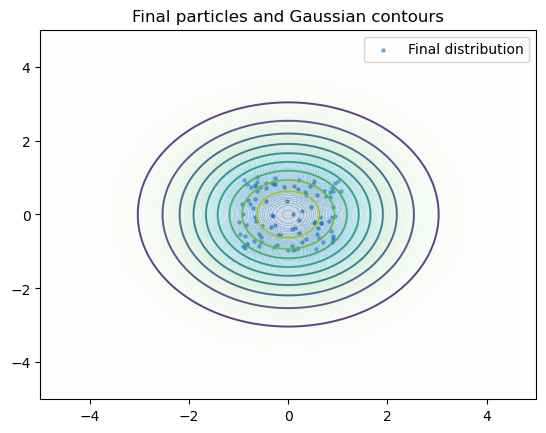

In [ ]:
plt.scatter(X_fin[:, 0], X_fin[:, 1], s=5, alpha=0.5,label='Final distribution')
#plt.scatter(X0[:, 0], X0[:, 1], s=1, alpha=0.5,label = 'Initial distribution')
plt.legend()

import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax.scipy.stats import multivariate_normal

# Paramètres de la distribution
mean = jnp.zeros(2)  # Moyenne (0, 0)
cov = jnp.eye(2) * 2.0  # Matrice de covariance (2 * identité)

# Grille pour les lignes de niveau
x = jnp.linspace(-5, 5, 100)
y = jnp.linspace(-5, 5, 100)
X, Y = jnp.meshgrid(x, y)
pos = jnp.dstack((X, Y))
Z = multivariate_normal.pdf(pos, mean=mean, cov=cov)

cf = plt.contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.2     # transparence du fond
    )

  # Lignes de contour par-dessus
plt.contour(
    X, Y, Z, 
    levels=10, 
    colors='black', 
    linewidths=0.8,
    alpha=0.5)
# Calcul de la densité de probabilité
Z = multivariate_normal.pdf(pos, mean, cov)

# 
plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')
plt.title("Final particles and Gaussian contours")
plt.legend()
plt.show()

# 4 MFNN 
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [1]:
import sys
import os

# Ajoute le dossier parent de `experiments` au path
sys.path.append(os.path.abspath("/Users/clementinechazal/Documents/these/Newcastle/kgd_code"))

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from modules.kgd_functions import F_P, GradientKernel,KernelGradientDiscrepancy, k_imq
from modules.variational_inference import VariationalInference


import jax
from jax import random

In [2]:
device_name = "cpu"

In [3]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

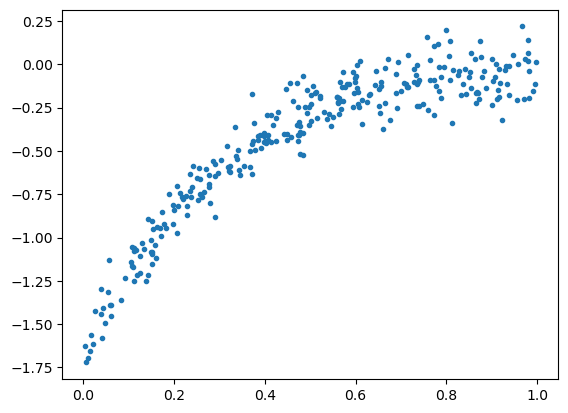

In [4]:
def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [0,1]

    def target_function(z):
        params = jnp.array([2, 0.5, 3, -3])
        return params[2]*jnp.tanh(params[0]*z.squeeze()+params[1]) + params[3]

    Y_clean = target_function(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z_train, Y_train = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
key, subkey = random.split(key)
Z_test, Y_test = generate_data(subkey, s, N=N, noise_std=0.1)

device = jax.devices()[0]
Z_train, Y_train = jax.device_put((Z_train, Y_train), device)
plt.plot(Z_train, Y_train, ".")

In [5]:

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*0.5))

def grad_log_q0(X):
    return -X/0.5

def L(X, unravel_fn, gamma):
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z_train)
    return gamma * jnp.mean((Esp_forward - Y_train) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)

gamma = 300
L_ = jit(lambda X: L(X, unravel_fn, gamma))

scale = 1e-0
k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))

learning_rate = 1e-3
VI = VariationalInference(grad_log_q0, L_, k, d, 20, learning_rate) 

In [6]:
T = 20000
n = 100

key = random.PRNGKey(3)
all_particles = VI.run_particles(key,T,n,gamma = gamma)
X_fin = all_particles[-1]

  0%|          | 14/20000 [00:00<13:32, 24.60it/s] 

Step 0, Loss: 35755.64453125, MSE 0.3065524101257324, Grad 42.47396469116211


  1%|          | 124/20000 [00:01<02:44, 120.88it/s]

Step 100, Loss: 37315.5078125, MSE 0.3501165807247162, Grad 108.38200378417969


  1%|          | 220/20000 [00:02<02:31, 130.41it/s]

...

 99%|█████████▉| 19817/20000 [02:46<00:01, 125.91it/s]

Step 19800, Loss: 64.08734893798828, MSE 0.018750347197055817, Grad 0.2720291316509247


100%|█████████▉| 19922/20000 [02:47<00:00, 120.24it/s]

Step 19900, Loss: 19.928314208984375, MSE 0.016765445470809937, Grad 0.10343887656927109


100%|██████████| 20000/20000 [02:48<00:00, 118.91it/s]


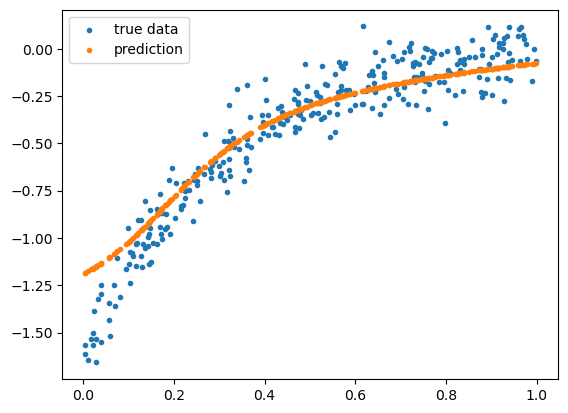

In [13]:
#Prediction function 
plt.scatter(Z_test,Y_test,label = "true data",marker = ".")
Y_hat = vmap(lambda z: forward_(X_fin, z, unravel_fn))(Z_test)
plt.scatter(Z_test,Y_hat,label = "prediction",marker = ".")
plt.legend()

Text(0, 0.5, 'dim4')

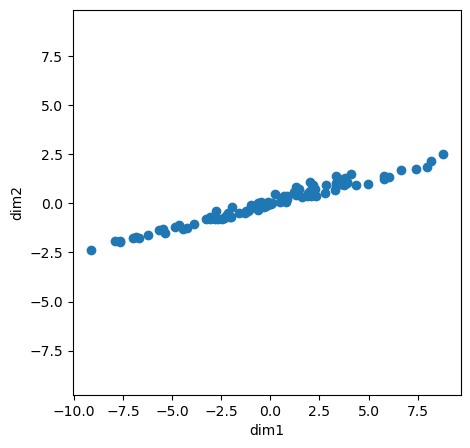

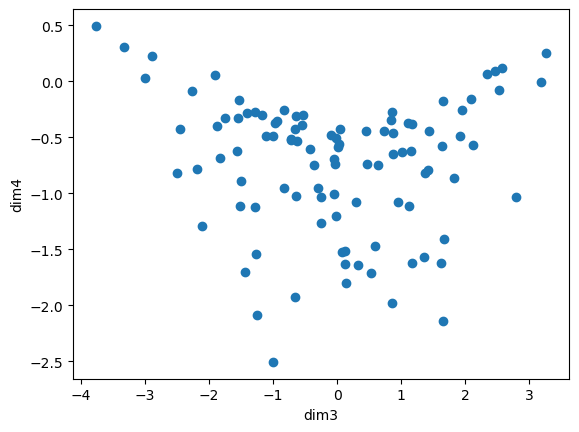

In [14]:
#Final particles positions
plt.figure(figsize = (5,5))
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.xlabel("dim1")
plt.ylabel("dim2")
plt.axis('equal')
plt.figure()
plt.scatter(X_fin[:,2], X_fin[:,3])
plt.xlabel("dim3")
plt.ylabel("dim4")

Text(0.5, 1.0, 'KGD values over iterations')

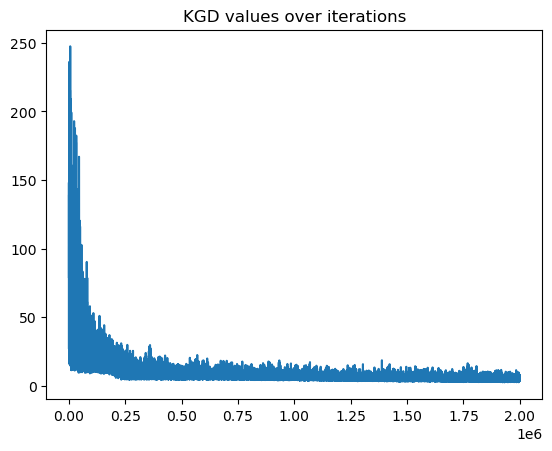

In [15]:
k_pq = GradientKernel(VI.S_PQ,k)
KGD = KernelGradientDiscrepancy(k_pq)

KGD_values = []
eval_gradL = jnp.arange(0,T)*n
for it in range(T):
    KGD_values.append(KGD.evaluate(all_particles[it]))
plt.plot(eval_gradL,KGD_values)
plt.title("KGD values over iterations")

# Save data

In [16]:
import jax.numpy as jnp
import pickle

# Chargement depuis le fichier
with open("saved_data/expe2_results.pkl", "rb") as g:
    expe2_results = pickle.load(g)

In [17]:
expe2_results["Variational Inference"]["X_fin"] = X_fin
expe2_results["Variational Inference"]["KGD_values"] = KGD_values
expe2_results["Variational Inference"]["gradL_eval"] = eval_gradL

In [18]:
import pickle

# Sauvegarde dans un fichier binaire
with open("saved_data/expe2_results.pkl", "wb") as gg:
    pickle.dump(expe2_results, gg)